In [10]:
import sys
import os
import pandas as pd
project_root = os.path.abspath("..")

if project_root not in sys.path:
    sys.path.append(project_root)

In [11]:
from src.sentiment_analysis import (
    load_news_data,
    add_sentiment_scores,
    aggregate_daily_sentiment
)

from src.stock_analysis import load_stock_data

from src.correlation_analysis import (
    merge_sentiment_with_returns,
    calculate_correlation,
    align_news_to_trading_days
)

from src.visualization import (
    plot_sentiment_vs_return,
    plot_average_return_by_sentiment
)


Analyzing AAPL...
AAPL Correlation: 1.0000
AAPL P-value: 1.0000


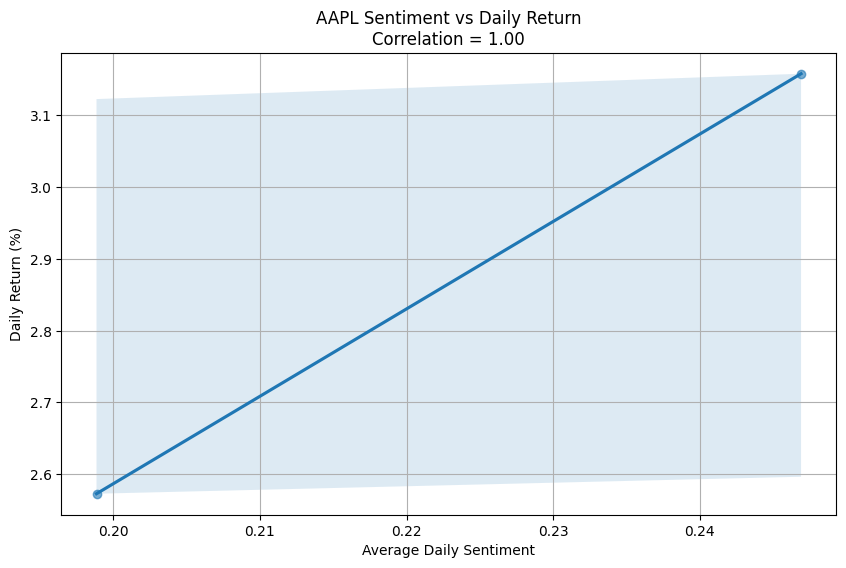

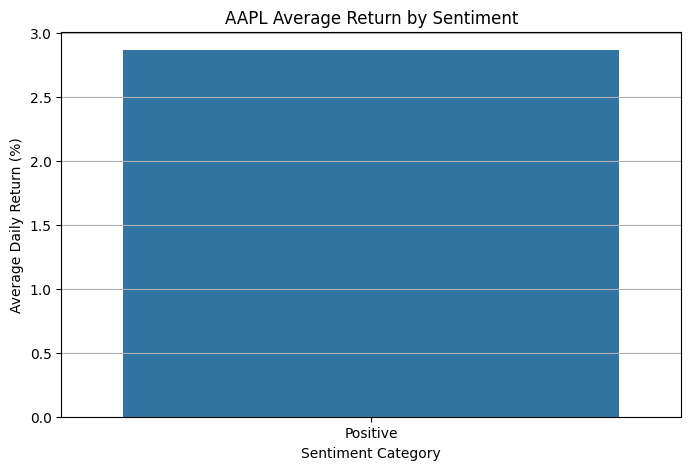


Analyzing AMZN...
AMZN Correlation: -1.0000
AMZN P-value: 1.0000


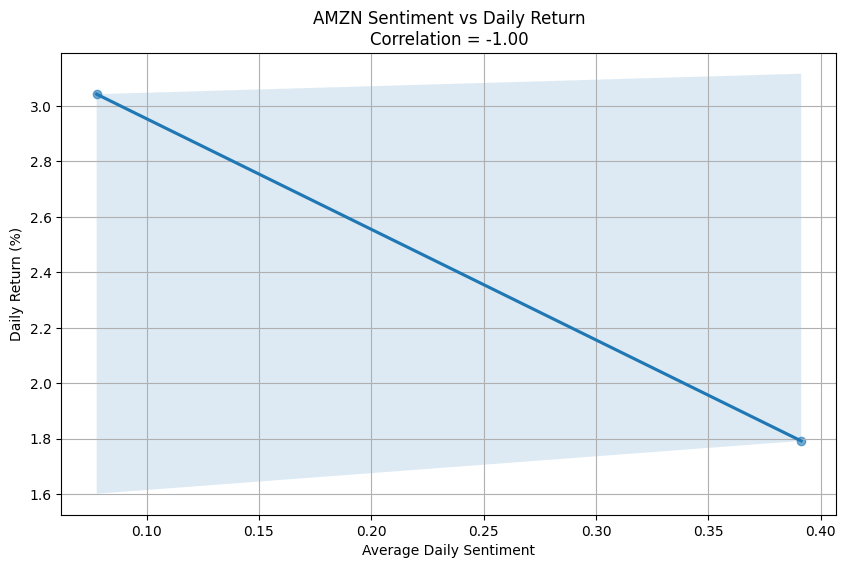

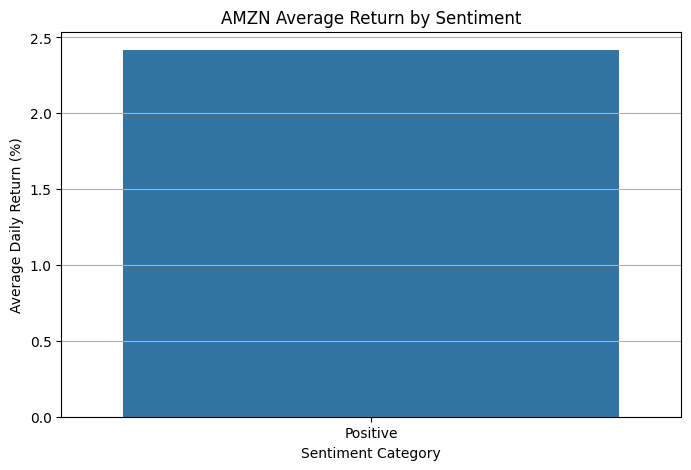


Analyzing GOOG...
GOOG Correlation: -0.2344
GOOG P-value: 0.7044


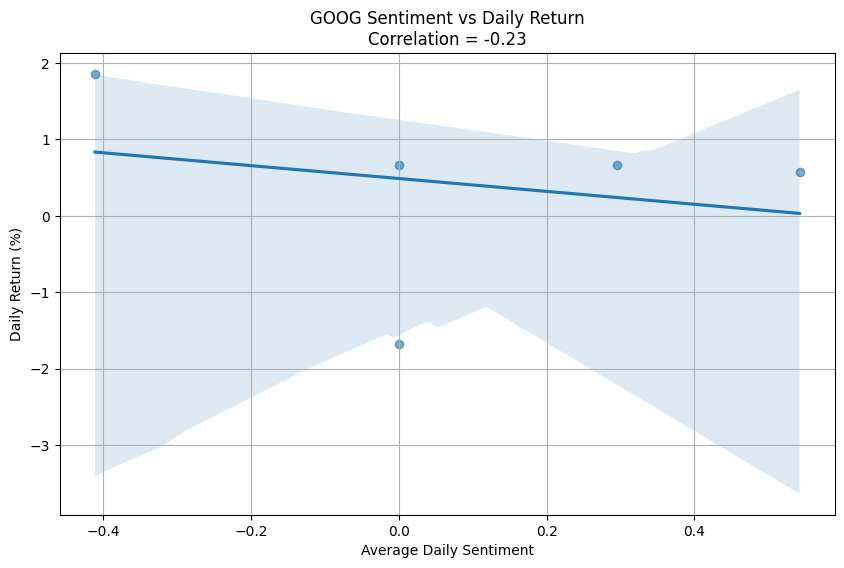

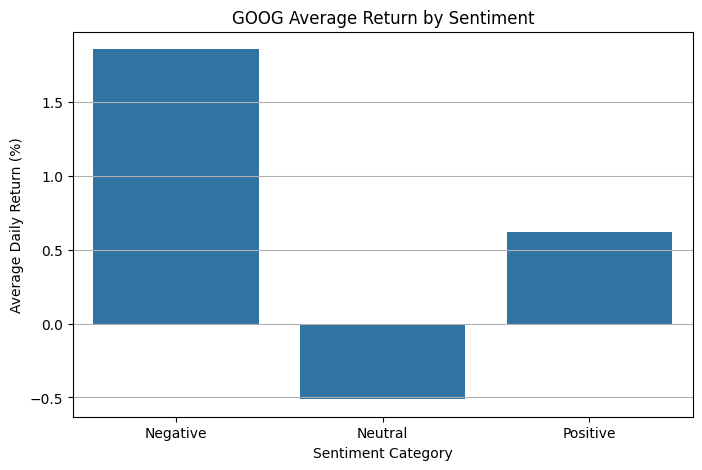


Analyzing META...
No matching sentiment and stock return data for META

Analyzing NVDA...
NVDA Correlation: 0.5227
NVDA P-value: 0.4773


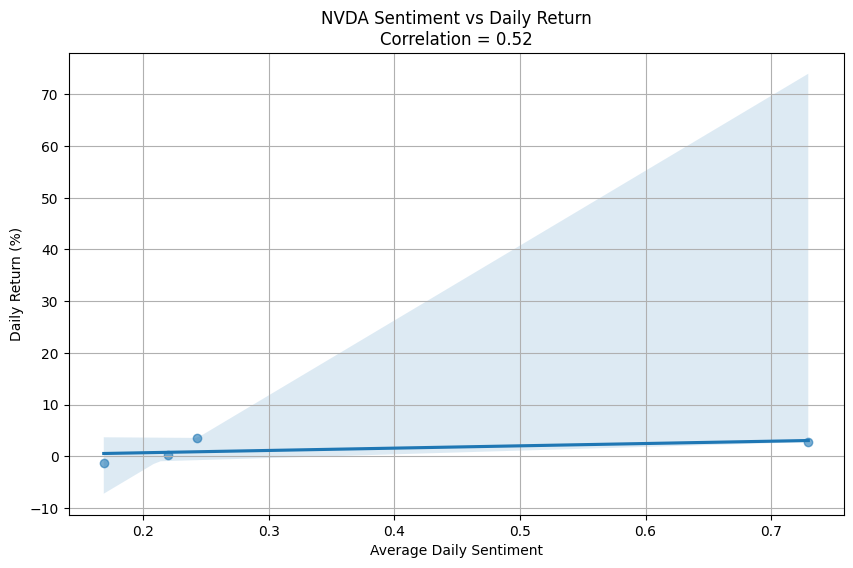

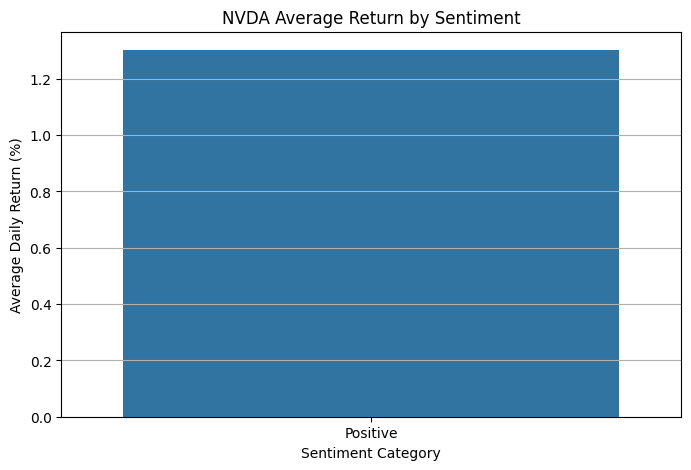

In [ ]:
news_path = "../data/raw/raw_analyst_ratings.csv"

stock_files = {
    "AAPL": "../data/raw/AAPL.csv",
    "AMZN": "../data/raw/AMZN.csv",
    "GOOG": "../data/raw/GOOG.csv",
    "META": "../data/raw/META.csv",
    "NVDA": "../data/raw/NVDA.csv"
}



news_df = load_news_data(news_path)
news_df = add_sentiment_scores(news_df)


results = []

for stock_symbol, stock_path in stock_files.items():

    print(f"\nAnalyzing {stock_symbol}...")

    stock_df = load_stock_data(stock_path)

    aligned_news_df = align_news_to_trading_days(
    news_df,
    stock_df
)

    daily_sentiment = aggregate_daily_sentiment(
        aligned_news_df,
        stock_symbol
    )

    merged_df = merge_sentiment_with_returns(
        stock_df,
        daily_sentiment
    )

    if merged_df.empty:
        print(f"No matching sentiment and stock return data for {stock_symbol}")
        continue

    correlation, p_value = calculate_correlation(merged_df)

    results.append({
        "stock": stock_symbol,
        "correlation": correlation,
        "p_value": p_value,
        "matched_days": len(merged_df)
    })

    print(f"{stock_symbol} Correlation: {correlation:.4f}")
    print(f"{stock_symbol} P-value: {p_value:.4f}")

    plot_sentiment_vs_return(
        merged_df,
        stock_symbol,
        correlation
    )

    plot_average_return_by_sentiment(
        merged_df,
        stock_symbol
    )




In [13]:
results_df = pd.DataFrame(results)

results_df

,stock,correlation,p_value,matched_days
0,AAPL,1.000000,1.000000,2
1,AMZN,-1.000000,1.000000,2
2,GOOG,-0.234365,0.704352,5
3,NVDA,0.522731,0.477269,4


Correlation Analysis Summary

The correlation analysis examined the relationship between average daily news sentiment and daily stock returns for several major technology companies. Pearson correlation coefficients were calculated after aligning news publication dates with stock trading days and aggregating sentiment scores by day.

The results showed varying relationships between sentiment and stock performance across companies. NVIDIA (NVDA) displayed a moderate positive correlation (0.52), suggesting that more positive news sentiment may be associated with higher stock returns. Google (GOOG) showed a weak negative correlation (-0.23), indicating little linear relationship between sentiment and daily returns during the analyzed period.

Apple (AAPL) and Amazon (AMZN) produced extreme correlation values of 1.0 and -1.0 respectively. However, these results are not reliable because they were based on only two matched trading days, which is too small for meaningful statistical interpretation. Similarly, the p-values across all stocks were relatively high, indicating that the observed correlations are not statistically significant.

Overall, the analysis suggests that financial news sentiment may have some influence on stock price movements, but the relationship appears weak and inconsistent across companies. The findings also highlight important limitations, including limited matched data points, possible lag effects between news publication and market reaction, and the influence of external market factors such as earnings reports, macroeconomic conditions, and investor sentiment.